# **Mini-Projet : Transformers et Systèmes RAG (Retrieval-Augmented Generation)**

## Filière : Ingénierie des Données – 2ème Année
### École Nationale des Sciences Appliquées d'Al Hoceima (ENSAH)

---
### Encadré par :
**Pr. Dr. TARIK BOUDAA**


### Réalisé par :
**Douae Laayouni**

---

### Année Universitaire
**2025 – 2026**

---



# **Partie I : Exploration des Transformers et tâches NLP**

## **Section 1 : Exploration de HuggingFace**



**1. Installation :**  
                                
Nous avons commencé par installer la bibliothèque Transformers de Hugging Face qui fournit des modèles pré-entraînés et des outils permettant de réaliser facilement différentes tâches NLP.

In [ ]:
pip install transformers

**2. Chargement d'un modèle pré-entraîné :**

J'ai décidé de charger un modèle de classification de texte.

In [ ]:
from transformers import pipeline

classifier = pipeline("text-classification")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

**3. Utilisation du Tokenizer:**

Même si Hugging Face utilise automatiquement un tokenizer dans le pipeline, nous avons étudié son fonctionnement afin de comprendre comment il facilite le prétraitement des données.
Nous avons chargé le tokenizer de BERT, car il s'agit d'un modèle Transformer de référence, largement utilisé pour les tâches de compréhension du langage naturel.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:

tokens = tokenizer.tokenize("I love NLP")
print(tokens)

['i', 'love', 'nl', '##p']


**4. Utilisation d'un Pipeline :**

Pour appliquer le modèle de classification, il suffit de fournir la phrase au pipeline.



La phrase est d'abord tokenisée puis envoyée dans les blocs Transformer de DistilBERT afin de produire une représentation contextuelle de l'ensemble de la séquence.Cette représentation est ensuite transmise à la tête de classification qui détermine la classe la plus probable.

In [ ]:
classifier("I love NLP")

[{'label': 'POSITIVE', 'score': 0.9997692704200745}]

##**Section 2 : Applications NLP**



## **1.Classification de texte :**








La classification de texte consiste à attribuer automatiquement une catégorie à un texte donné. Hugging Face permet de réaliser cette tâche en utilisant des modèles Transformers pré-entraînés.

Pour déterminer la classe associée à la phrase :
I love Natural Language Processing
il suffit d’utiliser la fonction pipeline en précisant la tâche à effectuer ainsi que le modèle
à utiliser. Dans ce cas, j'ai  utilisé le modèle :
distilbert-base-uncased-finetuned-sst-2-english
qui est un modèle déjà entraîné pour les tâches de classification de texte

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

result = classifier("I love Natural Language Processing")
print(result)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998213648796082}]


**Pourquoi DistilBERT ?**

DistilBERT est une version allégée de BERT proposée par Hugging Face. Il conserve des performances proches de BERT tout en étant plus rapide et plus léger.

Le livre utilise justement DistilBERT dans le chapitre 2.




## **2.Analyse de sentiment:**



Pour déterminer le sentiment associé à la phrase :

This course is excellent

il suffit d'utiliser un pipeline d'analyse de sentiment basé sur un modèle pré-entraîné. Le modèle analyse automatiquement le contenu de la phrase et prédit le sentiment correspondant. Dans notre cas, il a correctement identifié un sentiment positif.

In [ ]:
from transformers import pipeline

sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

sentiment("This course is excellent")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9998648166656494}]

J'ai désinstallé la version 5.9.0 de Transformers et installé la version 4.41.2 afin d'assurer la compatibilité avec certaines pipelines NLP comme question-answering, qui ne sont plus gérées de la même manière dans les versions récentes.

In [ ]:
!pip uninstall transformers -y
!pip install transformers==4.41.2

Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
  Using cached transformers-4.41.2-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.41.2-py3-none-any.whl (9.1 MB)




## **3.Question Answering :**






J'ai chargé un modèle pré-entraîné spécialisé dans le Question Answering. Je lui ai fourni un contexte indiquant par qui et quand le Transformer a été introduit, puis je lui ai posé la question :

Who introduced Transformers?

Le modèle a analysé le contexte et a correctement extrait la réponse :

Vaswani et al.

In [ ]:
from transformers import pipeline

qa = pipeline(
    "question-answering",
    model="distilbert-base-cased-distilled-squad"
)

context = """
Transformers were introduced in 2017 by Vaswani et al.
"""

question = "Who introduced Transformers?"

result = qa(
    question=question,
    context=context
)

print(result)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'score': 0.5708221793174744, 'start': 41, 'end': 54, 'answer': 'Vaswani et al'}


## **4.Résumé automatique :**

Dans cette tâche, j'ai utilisé un modèle pré-entraîné spécialisé dans le résumé automatique. Je lui ai fourni un texte décrivant les Transformers, puis j'ai défini certaines contraintes sur le résumé à générer, notamment une longueur minimale de 20 mots et une longueur maximale de 50 mots. Le modèle a analysé le contenu du texte et a généré automatiquement un résumé concis contenant les informations les plus importantes.

In [ ]:
from transformers import pipeline

# Chargement du modèle de résumé
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

# Texte à résumer
text = """
Transformers are deep learning models introduced in 2017 by Vaswani et al.
They are based on the self-attention mechanism and have revolutionized
Natural Language Processing. Unlike RNNs and LSTMs, Transformers process
all words in parallel, allowing faster training and better understanding
of long-range dependencies. They are used in many NLP tasks such as
text classification, sentiment analysis, question answering,
machine translation and text summarization.
"""

# Génération du résumé
summary = summarizer(
    text,
    max_length=50,
    min_length=20,
    do_sample=False
)

# Affichage du résumé
print("Texte original :")
print(text)

print("\nRésumé :")
print(summary[0]["summary_text"])

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Texte original :

Transformers are deep learning models introduced in 2017 by Vaswani et al.
They are based on the self-attention mechanism and have revolutionized
Natural Language Processing. Unlike RNNs and LSTMs, Transformers process
all words in parallel, allowing faster training and better understanding
of long-range dependencies. They are used in many NLP tasks such as
text classification, sentiment analysis, question answering,
machine translation and text summarization.


Résumé :
Transformers are deep learning models introduced in 2017 by Vaswani et al. They are based on the self-attention mechanism and have revolutionized Natural Language Processing.


# **Partie II : Implémentation d'un système LLM et d'un llm avec système RAG**



## **Objectif :**

Dans cette partie, nous allons implémenter et comparer deux approches :

- Un système basé uniquement sur un Large Language Model (LLM).
- Un système RAG (Retrieval-Augmented Generation) combinant un LLM avec une base de connaissances externe.

L'objectif est de développer **un assistant pédagogique capable de répondre à des questions concernant les Transformers et les systèmes RAG**.

## **Corpus documentaire :**

Le corpus documentaire utilisé dans ce projet est constitué de plusieurs ressources académiques, notamment :

- **Natural Language Processing with Transformers** (ouvrage fourni avec le mini-projet).
- **Speech and Language Processing** de Jurafsky & Martin.
- Divers documents et articles sur les Transformers.
- Divers documents et articles sur les systèmes RAG.

Ces documents seront utilisés pour construire la base de connaissances du système RAG.
## **Organisation de cette partie :**

### 1. Implémentation d'un LLM seul :

- Chargement du modèle génératif.
- Génération de réponses à partir de questions utilisateur.
- Analyse des résultats obtenus.

### 2. Implémentation d'un système RAG :

- Chargement du corpus documentaire.
- Découpage des documents en chunks.
- Génération des embeddings.
- Construction de la base vectorielle avec FAISS.
- Recherche des documents pertinents.
- Construction du prompt augmenté.
- Génération de la réponse à l'aide du LLM.

### 3. Démonstration et expérimentation :

- Tests sur plusieurs questions relatives au corpus.
- Comparaison des réponses obtenues avec et sans RAG.
- Analyse de l'apport du RAG sur la qualité des réponses.

##**Section 1 : Implémentation d'un LLM seul**

**1. Installation des bibliothèques :**

In [ ]:
# Installation de la version compatible de Transformers

!pip uninstall transformers -y
!pip install transformers==4.41.2

Found existing installation: transformers 5.10.2
Uninstalling transformers-5.10.2:
  Successfully uninstalled transformers-5.10.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 35.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.18.0
    Uninstalling huggingface_hub-1.18.0:
      Successfully uninstalled huggingface_hub-1.18.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


**2. Chargement du modèle génératif :**

J'ai choisi d'utiliser le modèle pré-entraîné **FLAN-T5** car il est spécialement conçu pour comprendre et suivre des instructions formulées en langage naturel.

 Il est capable de répondre à des questions, d'expliquer des concepts et de générer des réponses cohérentes sans nécessiter d'entraînement supplémentaire. Ces caractéristiques le rendent particulièrement adapté à la création d'un assistant pédagogique
dédié aux Transformers et aux systèmes RAG.

La **variable generator** contient un pipeline complet de génération de texte basé sur le modèle FLAN-T5.

Lorsque je lui fournis une question, Hugging Face exécute automatiquement toutes les étapes nécessaires : prétraitement du texte, tokenisation, passage dans le modèle Transformer, décodage de la sortie puis génération de la réponse finale. Ainsi, il suffit d'appeler le pipeline avec une requête pour obtenir directement la réponse du modèle.

In [ ]:
from transformers import pipeline
generator = pipeline( "text2text-generation", model="google/flan-t5-base" )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

**3. Génération d'une première réponse :**

Afin de vérifier le bon fonctionnement du modèle, nous lui posons une première question concernant les Transformers.

**question = Explain what a Transformer model is in Natural Language Processing.
?"**

In [ ]:
question = """
Explain what a Transformer model is in Natural Language Processing.
"""

response = generator(
    question,
    max_new_tokens=100
)

print(response[0]["generated_text"])

a neural network


On remarque que même si nous avons précisé une taille maximale de 100 nouveaux tokens, ce qui devrait logiquement permettre d'obtenir une réponse riche, le modèle a généré uniquement la réponse « a neural network ». Cela illustre une limite des LLM seuls, qui peuvent produire des réponses imprécises, ambiguës ou insuffisamment détaillées en l'absence d'un contexte spécialisé.

**4. Tests sur plusieurs questions :**

Afin de confirmer mon observation concernant les limites des LLM utilisés seuls, je vais évaluer leurs connaissances générales sur les Transformers et les systèmes RAG en leur posant plusieurs questions.

L'objectif est de vérifier si le modèle est capable de produire des réponses précises, complètes et suffisamment détaillées sans disposer d'une base documentaire externe.

In [ ]:
questions = [
    "What is Self-Attention?",
    "What is RAG?",
    "What is the role of embeddings?"
]

for q in questions:

    print("Question :", q)

    answer = generator(
        q,
        max_new_tokens=100
    )

    print("Réponse :", answer[0]["generated_text"])
    print("-" * 50)

Question : What is Self-Attention?
Réponse : self-attention
--------------------------------------------------
Question : What is RAG?
Réponse : racial agglomeration
--------------------------------------------------
Question : What is the role of embeddings?
Réponse : a tool for detecting a pattern
--------------------------------------------------


Les résultats obtenus montrent que le LLM seul ne fournit pas toujours des réponses correctes ou suffisamment détaillées. Par exemple, pour la question "What is Self-Attention?", le modèle s'est contenté de répéter le terme lui-même sans fournir d'explication.

Pour la question "What is RAG?", il a généré la réponse incorrecte "racial agglomeration". Enfin, pour la question portant sur le rôle des embeddings, la réponse obtenue est restée vague et peu informative.

### **Déduction :**

Ces observations mettent en évidence les limites des LLM lorsqu'ils ne disposent pas d'un contexte documentaire spécialisé. Les réponses obtenues peuvent être incomplètes, ambiguës ou parfois incorrectes.

Cette limitation justifie l'utilisation d'un système RAG dans la suite du projet afin d'étudier comment l'ajout d'une base documentaire externe peut améliorer la qualité des réponses générées par le LLM.

##**Section 2 : Implémentation d'un système RAG**



Dans cette partie, nous allons implémenter un système RAG. Cette architecture combine un LLM avec une base documentaire externe afin de fournir au modèle des connaissances spécialisées sur le domaine étudié et ainsi améliorer la pertinence, la précision et la richesse des réponses générées.

**1. Constitution de la base documentaire :**

Afin d'améliorer la qualité des réponses générées par le LLM, nous construisons une base documentaire spécialisée sur les Transformers et le Retrieval-Augmented Generation (RAG).

Cette base servira de source de connaissances externe lors de la phase de génération.

### **Sources documentaires utilisées :**

Afin de construire la base de connaissances du système RAG, nous avons utilisé plusieurs ressources académiques de référence portant sur les Transformers, les embeddings et le Retrieval-Augmented Generation (RAG).

### **Transformers :**

- **Attention Is All You Need** (Vaswani et al., 2017), article fondateur introduisant l'architecture Transformer.
- **Natural Language Processing with Transformers**, ouvrage fourni avec le mini-projet.
- **Speech and Language Processing (SLP3)** de Jurafsky & Martin, chapitre consacré aux Transformers.

### **RAG :**

- **Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks** (Lewis et al., 2020), article fondateur du RAG.
- **Speech and Language Processing (SLP3)** de Jurafsky & Martin, chapitre consacré au Retrieval-Augmented Generation.

### **Embeddings :**

- **Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks** (Reimers & Gurevych, 2019), utilisé pour comprendre le principe des embeddings sémantiques et de la recherche vectorielle.

### **Recherche vectorielle :**

- **The FAISS Library**, article présentant les méthodes d'indexation et de recherche dans les bases vectorielles utilisées pour retrouver efficacement les documents les plus pertinents.

Ces documents constituent une base documentaire fixe utilisée pour construire la base vectorielle du système RAG et enrichir les réponses générées par le LLM.

**2. Chargement des documents :**

In [ ]:
pdfs = [
    "NIPS-2017-attention-is-all-you-need-Paper.pdf",
    "Natural language processing with Transformers new version.pdf",
    "Retrieval-Augmented Generation for.pdf",
    "Sentence-BERT Sentence Embeddings using Siamese BERT-Networks.pdf",
    "THE FAISS LIBRARY.pdf",
    "attention.pdf",
    "rag.pdf",
    "transformer.pdf"
]

print("Nombre de documents :", len(pdfs))

for pdf in pdfs:
    print(pdf)

Nombre de documents : 8
NIPS-2017-attention-is-all-you-need-Paper.pdf
Natural language processing with Transformers new version.pdf
Retrieval-Augmented Generation for.pdf
Sentence-BERT Sentence Embeddings using Siamese BERT-Networks.pdf
THE FAISS LIBRARY.pdf
attention.pdf
rag.pdf
transformer.pdf


**3.Extraction du texte :**

Après avoir chargé les documents PDF, il est nécessaire d'extraire leur contenu textuel afin de pouvoir l'exploiter dans le système RAG.

Chaque document PDF est parcouru page par page afin d'extraire le texte qui servira à construire la base documentaire.

In [ ]:
!pip install transformers==4.41.2
!pip install sentence-transformers==3.0.1
!pip install faiss-cpu
!pip install pypdf

In [ ]:
!pip install pypdf

In [ ]:
from pypdf import PdfReader

documents = []

for pdf in pdfs:

    reader = PdfReader(pdf)

    text = ""

    for page in reader.pages:

        page_text = page.extract_text()

        if page_text:
            text += page_text + "\n"

    documents.append(text)

print("Nombre de documents :", len(documents))

Nombre de documents : 8


In [ ]:
print(documents[0][:2000])

Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗†
University of Toronto
aidan@cs.toronto.edu
Łukasz Kaiser∗
Google Brain
lukaszkaiser@google.com
Illia Polosukhin∗‡
illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer,
based solely on attention mechanisms, dispensing with recurrence and convolutions
entirely. Experiments on two machine translation tasks show these models to
be superior in quality while being more parallelizable and requiring signiﬁcantly
less time to train. Our model a

Le contenu textuel des documents a été extrait avec succès à l'aide de la bibliothèque pypdf. L'inspection des premiers caractères du document montre que les informations importantes (titre, auteurs, résumé, définitions et explications) sont correctement récupérées.


 **4.Nettoyage du corpus :**

Les PDF contiennent souvent du bruit (numéros de page, espaces multiples, caractères spéciaux, références isolées, équations mal extraites, etc.). Un prétraitement est donc appliqué afin de conserver uniquement l'information textuelle pertinente utilisée pour la recherche documentaire.


**Éléments supprimés :**

Numéros de page

Espaces multiples

Caractères spéciaux inutiles

Équations ou formules mal extraites

Références isolées

Texte provenant d'images ou de figures lorsqu'il est non pertinent


**Éléments conservés :**

Définitions

Explications

Concepts théoriques

Paragraphes techniques

Descriptions des méthodes et algorithmes

In [ ]:
import re

clean_texts = []

for text in documents:

    # Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text)

    # Suppression des caractères spéciaux inutiles
    text = re.sub(r'[^\w\s.,;:!?()-]', ' ', text)

    clean_texts.append(text.strip())

print("Nombre de documents nettoyés :", len(clean_texts))

Nombre de documents nettoyés : 8


In [ ]:
print(clean_texts[0][:1000])

Attention Is All You Need Ashish Vaswani  Google Brain avaswani google.com Noam Shazeer  Google Brain noam google.com Niki Parmar  Google Research nikip google.com Jakob Uszkoreit  Google Research usz google.com Llion Jones  Google Research llion google.com Aidan N. Gomez   University of Toronto aidan cs.toronto.edu Łukasz Kaiser  Google Brain lukaszkaiser google.com Illia Polosukhin   illia.polosukhin gmail.com Abstract The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring signiﬁcantly less time to train. Our model a

In [ ]:
print(type(documents))
print(type(documents[0]))
print(len(documents))

<class 'list'>
<class 'str'>
8


**5.Découpage en chunks :**

Les documents extraits restent volumineux et ne peuvent pas être directement utilisés lors de la recherche documentaire. Nous allons donc les découper en petits segments appelés chunks afin de faciliter leur représentation vectorielle et la recherche des informations pertinentes.

In [ ]:
!pip install -q langchain-text-splitters

In [ ]:
import re

chunks = []

chunk_size = 500

for text in clean_texts:

    sentences = re.split(r'(?<=[.!?])\s+', text)

    current_chunk = ""

    for sentence in sentences:

        if len(current_chunk) + len(sentence) <= chunk_size:

            current_chunk += " " + sentence

        else:

            if current_chunk:
                chunks.append(current_chunk.strip())

            current_chunk = sentence

    if current_chunk:
        chunks.append(current_chunk.strip())

print("Nombre de chunks :", len(chunks))

Nombre de chunks : 2616


Pour chaque document, nous construisons plusieurs chunks. Chaque chunk contient une partie cohérente de l'information du document, avec un chevauchement permettant de conserver le contexte entre deux chunks successifs. Au final, après le découpage des 8 documents de notre corpus, nous avons obtenu 2664 chunks qui représentent l'ensemble des connaissances utilisées par le système RAG.

**6. Génération des embeddings :**

Transformer chaque chunk en vecteur numérique représentant son sens sémantique.

***Installation du modèle d'embedding :***

In [ ]:
!pip install -q sentence-transformers==2.7.0

***Chargement du modèle d'embedding :***

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


***Génération des embeddings :***

Chaque chunk est transformé en un vecteur de 384 dimensions représentant son sens sémantique.

In [ ]:
embeddings = embedding_model.encode(
    chunks,
    show_progress_bar=True
)

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

***Vérification :***

In [ ]:
print(embeddings.shape)

(2616, 384)


**7. Construction de la base vectorielle :**

Dans cette étape, nous construisons une base vectorielle à l'aide de **FAISS** (Facebook AI Similarity Search) qui est une bibliothèque développée par Meta permettant de rechercher rapidement les vecteurs les plus similaires dans une base vectorielle.

 Les embeddings générés à partir des chunks sont indexés afin de permettre une recherche rapide des documents les plus pertinents.

  Chaque chunk est représenté par un vecteur numérique décrivant son sens sémantique. La base vectorielle est ensuite sauvegardée pour éviter de recalculer les embeddings à chaque exécution du système.
  
  Ainsi, lorsqu'une question est posée, il devient possible de retrouver rapidement les chunks les plus proches de cette question avant de les transmettre au LLM dans le cadre du processus RAG.

***Installation :***

In [ ]:
!pip install -q faiss-cpu

***Création de l'index FAISS :***


FAISS permet d'effectuer une recherche rapide dans l'espace vectoriel afin de retrouver les chunks les plus proches d'une requête.

In [ ]:
import faiss
import numpy as np

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(
    np.array(embeddings).astype("float32")
)

print("Nombre de vecteurs indexés :", index.ntotal)

Nombre de vecteurs indexés : 2616


***Sauvegarde de la base vectorielle FAISS :***

In [ ]:
faiss.write_index(
    index,
    "rag_index.faiss"
)


***Sauvegarde des chunks:***

In [ ]:
import pickle

with open("chunks.pkl", "wb") as f:
    pickle.dump(chunks, f)

Dans cette étape, la base vectorielle construite avec FAISS est sauvegardée dans le fichier rag_index.faiss. Les chunks utilisés pour générer les embeddings sont également enregistrés dans le fichier chunks.pkl.

Cette sauvegarde permet de réutiliser ultérieurement la base documentaire sans avoir à relire les PDF, redécouper les documents ou recalculer les embeddings, ce qui réduit considérablement le temps d'exécution du système RAG.

**8. Recherche des documents pertinents :**

L'objectif de cette étape est d'identifier, parmi tous les chunks stockés dans la base vectorielle, ceux qui sont les plus pertinents pour répondre à la question posée par l'utilisateur.

Pour cela, la question est d'abord transformée en embedding à l'aide du même modèle utilisé pour les documents. Cet embedding est ensuite comparé aux embeddings présents dans la base vectorielle FAISS afin de retrouver les chunks dont le contenu est le plus proche sémantiquement de la question.

Dans cet exemple, nous cherchons à répondre à la question :

question = "What is Self-Attention?"


***Question de test:***

In [ ]:
question = "What is Self-Attention?"

***Génération de l'embedding de la question:***

In [ ]:

question_embedding = embedding_model.encode(
    [question]
)

***Recherche des Top-3 chunks:***

In [ ]:
D, I = index.search(
    question_embedding.astype("float32"),
    k=3
)

***Affichage des résultats:***

In [ ]:
for rank, idx in enumerate(I[0]):

    print(f"\nTop {rank+1}")

    print(chunks[idx][:500])

    print("-" * 80)


Top 1
The  self  part of self- attention refers to the fact that these weights are computed for all hidden states in the same set for example, all the hidden states of the encoder. By contrast, the attention mechanism associated with recurrent models involves computing the relevance of each encoder hidden state to the decoder hidden state at a given decoding timestep.
--------------------------------------------------------------------------------

Top 2
The main idea behind self-attention is that instead of using a fixed embedding for each token, we can use the whole sequence to compute a weighted average of each embedding. Another way to formulate this is to say that given a sequence of token embeddings x 1 , ... , x n , self-attention produces a sequence of new embeddings x 1   , ...
--------------------------------------------------------------------------------

Top 3
Let s take a quick look at some of themost popular approaches to make self-attention more efficient, starting wit

On remarque que les trois chunks récupérés sont directement liés au mécanisme de Self-Attention. Contrairement aux premiers résultats obtenus, les passages retrouvés sont maintenant cohérents, complets et contiennent des informations pertinentes sur le sujet recherché.

Cela montre que le découpage en chunks, la génération des embeddings et la recherche vectorielle avec FAISS fonctionnent correctement. Le système est désormais capable de retrouver les informations les plus utiles pour construire le contexte qui sera envoyé au LLM dans l'étape suivante.


**8. Construction du prompt augmenté :**

Construire automatiquement le contexte qui sera envoyé au LLM.

In [ ]:
context = "\n\n".join(
    [chunks[idx] for idx in I[0]]
)

In [ ]:
prompt = f"""
Answer the question using only the context below.

Context:
{context}

Question:
{question}
"""

***Affichage du prompt final:***

In [ ]:
print(prompt)


Answer the question using only the context below.

Context:
The  self  part of self- attention refers to the fact that these weights are computed for all hidden states in the same set for example, all the hidden states of the encoder. By contrast, the attention mechanism associated with recurrent models involves computing the relevance of each encoder hidden state to the decoder hidden state at a given decoding timestep.

The main idea behind self-attention is that instead of using a fixed embedding for each token, we can use the whole sequence to compute a weighted average of each embedding. Another way to formulate this is to say that given a sequence of token embeddings x 1 , ... , x n , self-attention produces a sequence of new embeddings x 1   , ...

Let s take a quick look at some of themost popular approaches to make self-attention more efficient, starting with sparsity. 5 6 Sparse Attention One way to reduce the number of computations that are performed in the self-attention l


**9. Construction du prompt augmenté :**

***Chargement du modèle:***

In [ ]:
from transformers import pipeline

generator = pipeline(
    "text2text-generation",
    model="google/flan-t5-base"
)

***Génération de la réponse:***

In [ ]:
response = generator(
    prompt,
    max_new_tokens=100
)

print(response[0]["generated_text"])

The main idea behind self-attention is that instead of using a fixed embedding for each token, we can use the whole sequence to compute a weighted average of each embedding


On remarque que grâce au RAG, le LLM est maintenant capable de générer une réponse riche et pertinente.

 Il explique correctement que le Self-Attention utilise toute la séquence afin de calculer l'importance de chaque mot dans le contexte.

 Cela montre que l'ajout d'une base de connaissances externe permet d'améliorer considérablement la qualité des réponses générées.

**9. Tests sur plusieurs questions:**

Pour que la comparaison soit la plus logique et la plus réaliste possible, j'ai utilisé les mêmes questions que celles déjà posées au LLM seul. Ainsi, toute différence observée dans les réponses proviendra de l'ajout du système RAG et non d'un changement des questions utilisées.

***Questions utilisées***

```python
questions = [
    "Explain what a Transformer model is in Natural Language Processing.",
    "What is Self-Attention?",
    "What is RAG?",
    "What is the role of embeddings?"
]
```

In [ ]:
questions = [
    "Explain what a Transformer model is in Natural Language Processing.",
    "What is Self-Attention?",
    "What is RAG?",
    "What is the role of embeddings?"
]

In [ ]:
for question in questions:

    question_embedding = embedding_model.encode([question])

    D, I = index.search(
        question_embedding.astype("float32"),
        k=3
    )

    context = "\n\n".join(
        [chunks[idx] for idx in I[0]]
    )

    prompt = f"""
    Answer the question using only the context below.

    Context:
    {context}

    Question:
    {question}
    """

    response = generator(
        prompt,
        max_new_tokens=100
    )

    print("\nQuestion :", question)
    print("\nRéponse :")
    print(response[0]["generated_text"])
    print("-" * 100)


Question : Explain what a Transformer model is in Natural Language Processing.

Réponse :
transformer-based large language models
----------------------------------------------------------------------------------------------------

Question : What is Self-Attention?

Réponse :
The main idea behind self-attention is that instead of using a fixed embedding for each token, we can use the whole sequence to compute a weighted average of each embedding
----------------------------------------------------------------------------------------------------

Question : What is RAG?

Réponse :
language models
----------------------------------------------------------------------------------------------------

Question : What is the role of embeddings?

Réponse :
bound by an embedding contract on the embedding distance
----------------------------------------------------------------------------------------------------


**10. Analyse des résultats:**


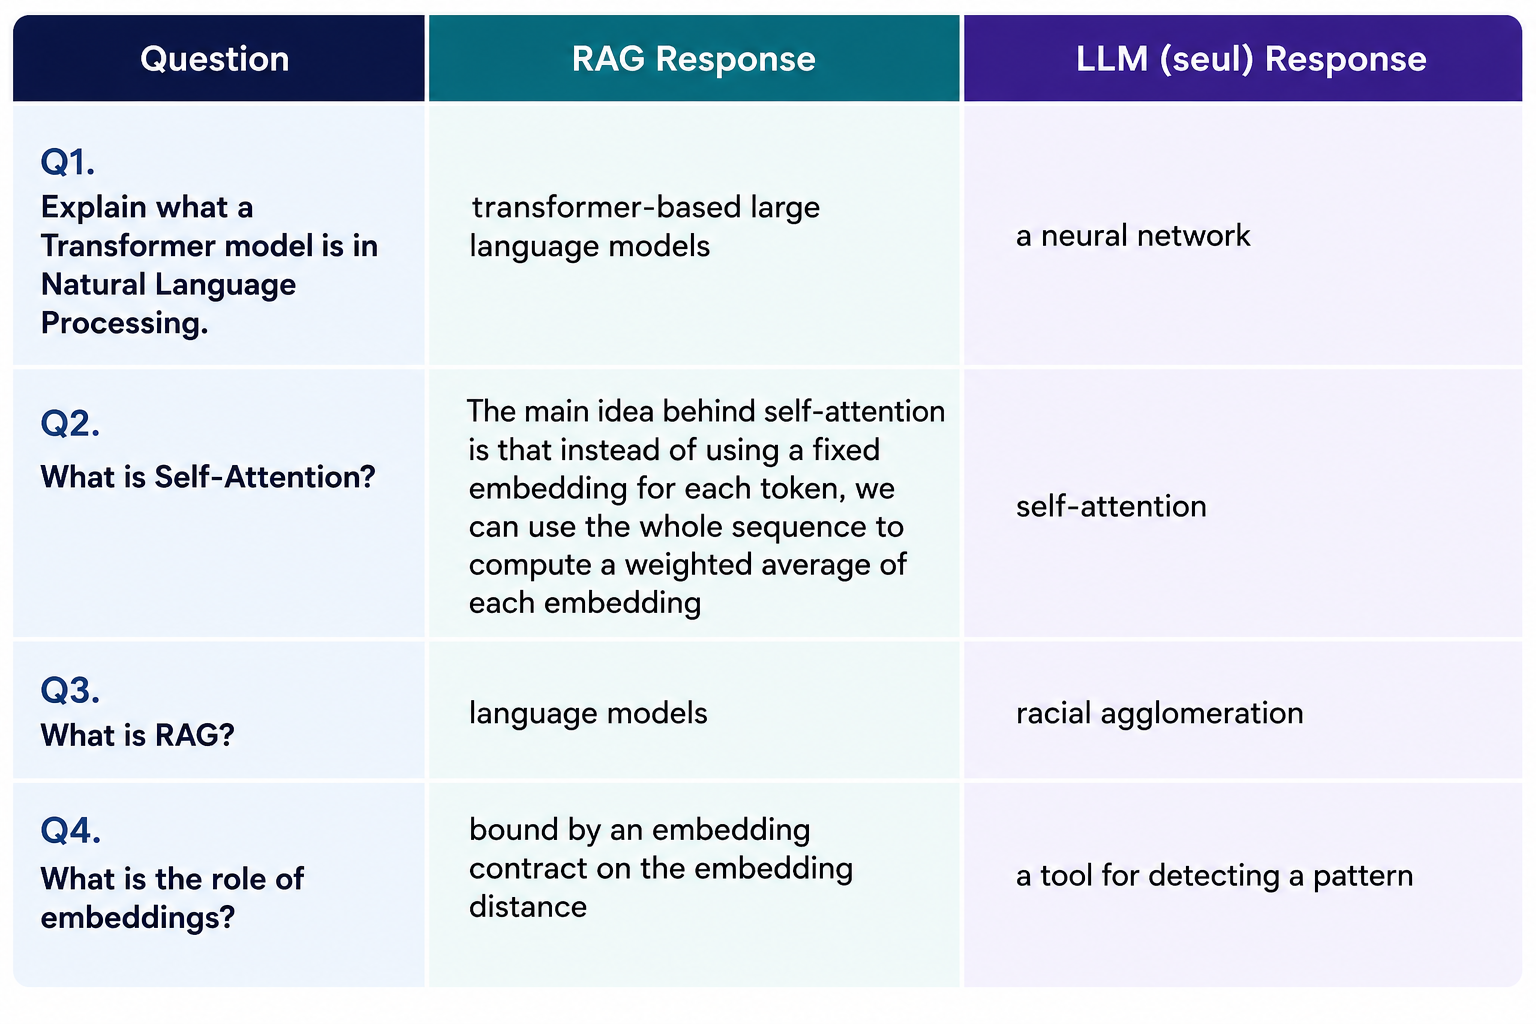



**Conclusion:**


*   Grâce à ce travail réalisé, j’ai bien saisi la puissance de la bibliothèque Hugging Face qui permet de faciliter l’utilisation des Transformers et de les appliquer facilement à différentes tâches de traitement du langage naturel. J’ai également mieux compris le principe du transfert d’apprentissage (Transfer Learning), qui permet de réutiliser des modèles pré-entraînés sans avoir à les entraîner depuis zéro.

*   L’analyse des résultats obtenus m’a également permis de saisir le rôle crucial des systèmes RAG et de comprendre comment ils permettent aux LLM de générer des réponses plus riches, plus pertinentes et plus correctes grâce à l’utilisation d’une base documentaire externe. À l’inverse, les résultats montrent qu’un LLM utilisé seul reste moins performant lorsqu’il ne dispose pas d’un contexte documentaire spécialisé.








